5.7
Error Propagation in Downstream NLP Tasks\
This case study investigates how parsing errors affect downstream applications such as machine translation and information extraction. It compares how mistakes in constituency boundaries versus incorrect dependency arcs influence semantic role labeling. Using benchmarks from Stanford NLP Group tools, the study proposes hybrid parsing representations to mitigate cascading errors and improve robustness.

In many NLP pipelines, syntactic parsing serves as an intermediate step for more complex downstream tasks. When parsing errors occur, they can propagate further through the system and negatively affect later stages of processing. This phenomenon, known as error propagation, raises important questions about the robustness of downstream models.

In this case study, I examine how syntactic parsing errors influence Semantic Role Labeling (SRL). Specifically, I compare the effects of corrupted dependency arcs and incorrect constituency boundaries on SRL performance. Also, I test a simple hybrid approach that combines information from both parsing representations in order to reduce the impact of cascading errors.

In [18]:
# !pip install stanza
# !pip install pandas
# !pip install scikit-learn
# !pip install matplotlib seaborn

Here I import necessary libraries

In [19]:
import random
import copy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import numpy as np
import stanza

Here I download the English Stanza models and initialize a processing pipeline that performs tokenization, POS tagging, lemmatization, dependency parsing, and constituency parsing for each input sentence.

In [20]:
stanza.download('en')

nlp = stanza.Pipeline(
    'en',
    processors='tokenize,pos,lemma,depparse,constituency'
)

2026-04-21 18:20:13 INFO: Downloaded file to C:\Users\admin\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\resources.json
2026-04-21 18:20:13 INFO: Downloading default packages for language: en (English) ...
2026-04-21 18:20:14 INFO: File exists: C:\Users\admin\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\en\default.zip
2026-04-21 18:20:17 INFO: Finished downloading models and saved to C:\Users\admin\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources
2026-04-21 18:20:17 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-04-21 18:20:24 INFO: Downloaded file to C:\Users\admin\AppData\Local\StanfordNLP\stanza\Cache\1.11.0\resources\resources.json
2026-04-21 18:20:24 WARNING: Language en package default expects mwt, which has been added
2026-04-21 18:20:25 INFO: Loading these models for language: en (English):
| Processor    | Package             |
--------------------------------------
| tokenize     | combined            |
| mwt          | combined            |
| pos          | combined_charlm     |
| lemma        | combined_nocharlm   |
| constituency | ptb3-revised_charlm |
| depparse     | combined_charlm     |

2026-04-21 18:20:25 INFO: Using device: cpu
2026-04-21 18:20:25 INFO: Loading: tokenize
2026-04-21 18:20:25 INFO: Loading: mwt
2026-04-21 18:20:25 INFO: Loading: pos
2026-04-21 18:20:27 INFO: Loading: lemma
2026-04-21 18:20:27 INFO: Loading: constituency
2026-04-21 18:20:28 INFO: Loading: depparse
2026-04-21 18:20:28 INFO: Done loading processors!


Here there is a function that implements a simple rule-based SRL system on top of dependency parsing by identifying verbs as predicates and extracting their arguments based on dependency relations

In [21]:
def simple_srl_from_doc(doc):
    roles = []

    # Iterate over sentences in the parsed document
    for sent in doc.sentences:
        # Look for verbs that will serve as predicates
        for word in sent.words:
            if word.upos == "VERB":
                predicate = word.text
                args = {"V": predicate}  # Initialize semantic frame with the verb

                # Find dependents of the verb using dependency arcs
                for w in sent.words:
                    if w.head == word.id:
                        # Map syntactic relations to semantic roles
                        if w.deprel == "nsubj":
                            args["ARG0"] = w.text  # Agent
                        elif w.deprel in ["obj", "dobj"]:
                            args["ARG1"] = w.text  # Direct object
                        elif w.deprel == "iobj":
                            args["ARG2"] = w.text  # Indirect object

                roles.append(args)

    return roles

Here I create a dictionary to use it for "breaking"

In [22]:
sentences = [
    "John gave Mary a book.",
    "Alice sent Bob an email.",
    "The teacher explained the lesson.",
    "Tom bought a car.",
    "Sarah wrote a letter.",
    "The company hired a manager.",
    "The chef cooked dinner.",
    "The dog chased the cat.",
    "Anna told a story.",
    "Mark built a house.",
    "Emily prepared breakfast.",
    "David opened the window.",
    "The manager approved the proposal.",
    "Lisa borrowed a laptop.",
    "The scientist conducted an experiment.",
    "Peter fixed the computer.",
    "The artist painted a portrait.",
    "The boy kicked the ball.",
    "The judge announced the decision.",
    "The farmer planted crops."
]

The dependency-based SRL method relies on syntactic head–dependent relations to extract semantic roles. In this approach, verbs are treated as predicates, and their arguments are identified based on dependency labels such as nsubj, obj, and iobj. Since semantic roles are directly tied to dependency arcs, errors in head assignments can significantly affect role extraction

There is a function that simulates dependency parsing errors by randomly reassigning head relations with a given corruption probability

In [23]:
def corrupt_dependencies(doc, corruption_rate=0.3):
    # Create a deep copy so the original parsed document remains unchanged
    corrupted_doc = copy.deepcopy(doc)

    for sent in corrupted_doc.sentences:
        words = sent.words
        for word in words:
            # With a given probability, randomly change the syntactic head
            if random.random() < corruption_rate and word.head != 0:
                possible_heads = [w.id for w in words if w.id != word.id]
                word.head = random.choice(possible_heads)

    return corrupted_doc

There are functions that convert extracted semantic roles into comparable sets and compute precision, recall, and F1-score between gold and predicted SRL outputs

In [24]:
def roles_to_set(role_list):
    role_set = set()

    # Convert each semantic frame into (predicate, role, argument) tuples
    for frame in role_list:
        predicate = frame.get("V")
        for role, arg in frame.items():
            if role != "V":
                role_set.add((predicate, role, arg))
    return role_set


def compare_roles(gold_roles, pred_roles):
    # Transform role dictionaries into comparable sets
    gold_set = roles_to_set(gold_roles)
    pred_set = roles_to_set(pred_roles)

    # Compute overlap and differences
    true_pos = len(gold_set & pred_set)
    false_pos = len(pred_set - gold_set)
    false_neg = len(gold_set - pred_set)

    # Calculate evaluation metrics
    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
    recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1

Here there is a block that runs the dependency-based experiment by applying different levels of synthetic corruption and measuring the average SRL performance across multiple sentences and runs

In [25]:
corruption_levels = [0.0, 0.1, 0.3, 0.5, 0.7]
runs = 10

means = []
stds = []

# Iterate over different corruption intensities
for level in corruption_levels:
    all_f1_scores = []

    for sentence in sentences:
        doc = nlp(sentence)
        baseline_roles = simple_srl_from_doc(doc)  # Gold SRL from clean parse

        # Repeat corruption multiple times for stability
        for i in range(runs):
            corrupted_doc = corrupt_dependencies(doc, corruption_rate=level)
            corrupted_roles = simple_srl_from_doc(corrupted_doc)

            _, _, f1 = compare_roles(baseline_roles, corrupted_roles)
            all_f1_scores.append(f1)

    # Compute mean and variance of performance
    avg_f1 = np.mean(all_f1_scores)
    std_f1 = np.std(all_f1_scores)

    means.append(avg_f1)
    stds.append(std_f1)

    print(f"Corruption {level}: Average F1 = {avg_f1}, Std = {std_f1}")

Corruption 0.0: Average F1 = 1.0, Std = 0.0
Corruption 0.1: Average F1 = 0.9505, Std = 0.12260947489216865
Corruption 0.3: Average F1 = 0.8088333333333333, Std = 0.283126934626699
Corruption 0.5: Average F1 = 0.7016666666666667, Std = 0.3174507835869995
Corruption 0.7: Average F1 = 0.58, Std = 0.362537354397217


Here we can show visual results

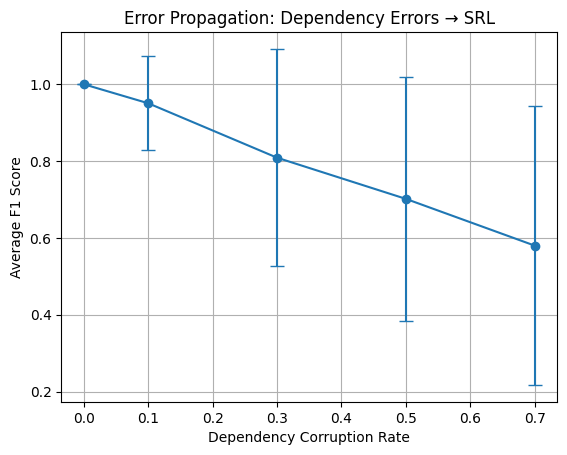

In [26]:
plt.errorbar(corruption_levels, means, yerr=stds, marker='o', capsize=5)
plt.xlabel("Dependency Corruption Rate")
plt.ylabel("Average F1 Score")
plt.title("Error Propagation: Dependency Errors → SRL")
plt.grid(True)
plt.show()

The constituency-based SRL method uses phrase structure information instead of head–dependent relations. Here, arguments are extracted from NP–VP configurations in the parse tree, where the subject is typically identified from the sentence-level NP and the object from an NP inside the VP. Because this approach relies on phrase boundaries rather than dependency arcs, it reacts differently to structural corruption

Here there is a block that implements a simple constituency-based SRL approach by extracting subjects and objects from NP–VP structures in the parse tree

In [27]:
def get_first_label(node, label):
    # Recursively search for the first node with a given syntactic label
    if node.label == label:
        return node

    for child in node.children:
        result = get_first_label(child, label)
        if result:
            return result

    return None


def get_first_verb(node):
    # Recursively find the first verb inside a subtree
    if node.label.startswith("VB"):
        return node.leaf_labels()[0]

    for child in node.children:
        result = get_first_verb(child)
        if result:
            return result

    return None


def simple_srl_from_constituency(doc):
    roles = []

    for sent in doc.sentences:
        tree = sent.constituency

        # Move from ROOT to sentence-level node (S)
        if tree.label == "ROOT" and len(tree.children) > 0:
            tree = tree.children[0]

        args = {}

        # Identify subject (NP) and predicate phrase (VP)
        subject_np = None
        vp = None

        for child in tree.children:
            if child.label == "NP" and subject_np is None:
                subject_np = child
            elif child.label == "VP" and vp is None:
                vp = child

        # ARG0 from sentence-level NP
        if subject_np:
            args["ARG0"] = " ".join(subject_np.leaf_labels())

        # Extract verb and object from VP subtree
        if vp:
            verb = get_first_verb(vp)
            if verb:
                args["V"] = verb

            obj_np = get_first_label(vp, "NP")
            if obj_np:
                args["ARG1"] = " ".join(obj_np.leaf_labels())

        if "V" in args:
            roles.append(args)

    return roles

This function simulates constituency parsing errors by randomly removing NP nodes inside the VP with a given probability. In this way, we imitate boundary mistakes in phrase structure and observe how they affect SRL extraction.

In [28]:
def corrupt_constituency(doc, corruption_rate=0.3):
    # Create a copy to avoid modifying the original parse tree
    corrupted_doc = copy.deepcopy(doc)

    for sent in corrupted_doc.sentences:
        tree = sent.constituency

        # Move from ROOT to sentence-level node (S)
        if tree.label == "ROOT" and len(tree.children) > 0:
            tree = tree.children[0]

        # Locate the main VP in the sentence
        vp = None
        for child in tree.children:
            if child.label == "VP":
                vp = child
                break

        if vp:
            new_children = []
            for child in vp.children:
                # Randomly remove NP nodes to simulate boundary errors
                if child.label == "NP" and random.random() < corruption_rate:
                    continue
                new_children.append(child)

            vp.children = new_children

    return corrupted_doc

Here a block that runs the constituency-based experiment by applying different levels of structural corruption to the parse tree. For each corruption level, we measure the average SRL performance and its variability across multiple sentences and runs.

In [29]:
means_const = []
stds_const = []

# Iterate over different corruption levels
for level in corruption_levels:
    all_f1_scores = []

    for sentence in sentences:
        doc = nlp(sentence)
        baseline_roles = simple_srl_from_constituency(doc)  # Gold SRL from clean tree

        # Apply corruption multiple times for stability
        for i in range(runs):
            corrupted_doc = corrupt_constituency(doc, corruption_rate=level)
            corrupted_roles = simple_srl_from_constituency(corrupted_doc)

            _, _, f1 = compare_roles(baseline_roles, corrupted_roles)
            all_f1_scores.append(f1)

    # Compute average performance and variability
    avg_f1 = np.mean(all_f1_scores)
    std_f1 = np.std(all_f1_scores)

    means_const.append(avg_f1)
    stds_const.append(std_f1)

    print(f"[Constituency] Corruption {level}: Average F1 = {avg_f1}, Std = {std_f1}")

[Constituency] Corruption 0.0: Average F1 = 1.0, Std = 0.0
[Constituency] Corruption 0.1: Average F1 = 0.9725, Std = 0.09395255895042633
[Constituency] Corruption 0.3: Average F1 = 0.9074999999999999, Std = 0.15607823892736192
[Constituency] Corruption 0.5: Average F1 = 0.8375, Std = 0.17275343701356566
[Constituency] Corruption 0.7: Average F1 = 0.7816666666666666, Std = 0.16363068171953574


Here we can show visual results

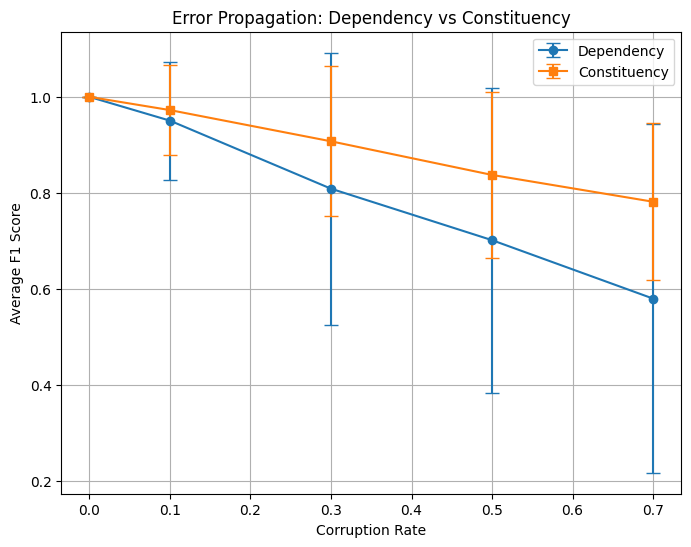

In [30]:
plt.figure(figsize=(8,6))

plt.errorbar(corruption_levels, means, yerr=stds, marker='o', capsize=5, label="Dependency")
plt.errorbar(corruption_levels, means_const, yerr=stds_const, marker='s', capsize=5, label="Constituency")

plt.xlabel("Corruption Rate")
plt.ylabel("Average F1 Score")
plt.title("Error Propagation: Dependency vs Constituency")
plt.legend()
plt.grid(True)
plt.show()

The hybrid approach combines information from both dependency and constituency parses in order to reduce the impact of errors from any single syntactic representation

Here a function that we merge the SRL outputs from both methods by aligning frames based on the verb. For each predicate, we keep the available arguments from dependency parsing first and fall back to constituency-based extraction if needed

In [31]:
def hybrid_srl(doc):
    # Extract roles independently from both parsing strategies
    dep_roles = simple_srl_from_doc(doc)
    const_roles = simple_srl_from_constituency(doc)

    # Create dictionaries indexed by verb (pred)
    dep_dict = {frame["V"]: frame for frame in dep_roles if "V" in frame}
    const_dict = {frame["V"]: frame for frame in const_roles if "V" in frame}

    # Collect all unique predicates from both sources
    all_verbs = set(dep_dict.keys()) | set(const_dict.keys())

    hybrid_roles = []

    for verb in all_verbs:
        hybrid_frame = {"V": verb}

        dep_frame = dep_dict.get(verb, {})
        const_frame = const_dict.get(verb, {})

        # Prefer dependency ARG0, otherwise fallback to constituency
        if "ARG0" in dep_frame:
            hybrid_frame["ARG0"] = dep_frame["ARG0"]
        elif "ARG0" in const_frame:
            hybrid_frame["ARG0"] = const_frame["ARG0"]

        # Prefer dependency ARG1, otherwise fallback to constituency
        if "ARG1" in dep_frame:
            hybrid_frame["ARG1"] = dep_frame["ARG1"]
        elif "ARG1" in const_frame:
            hybrid_frame["ARG1"] = const_frame["ARG1"]

        # ARG2 is taken only from dependency parsing
        if "ARG2" in dep_frame:
            hybrid_frame["ARG2"] = dep_frame["ARG2"]

        hybrid_roles.append(hybrid_frame)

    return hybrid_roles

Here we compare hybrid SRL on clean parses with hybrid SRL after applying dependency noise. This allows us to see whether the hybrid approach can better handle corrupted syntactic structures

In [32]:
means_hybrid = []
stds_hybrid = []

for level in corruption_levels:
    all_f1_scores = []

    for sentence in sentences:
        clean_doc = nlp(sentence)

        baseline_roles = hybrid_srl(clean_doc)

        for i in range(runs):
            corrupted_doc = corrupt_dependencies(clean_doc, corruption_rate=level)

            hybrid_roles_corrupted = hybrid_srl(corrupted_doc)

            _, _, f1 = compare_roles(baseline_roles, hybrid_roles_corrupted)
            all_f1_scores.append(f1)

    avg_f1 = np.mean(all_f1_scores)
    std_f1 = np.std(all_f1_scores)

    means_hybrid.append(avg_f1)
    stds_hybrid.append(std_f1)

    print(f"[Hybrid - Dep Noise] Corruption {level}: Average F1 = {avg_f1}, Std = {std_f1}")

[Hybrid - Dep Noise] Corruption 0.0: Average F1 = 1.0, Std = 0.0
[Hybrid - Dep Noise] Corruption 0.1: Average F1 = 0.96, Std = 0.1345362404707371
[Hybrid - Dep Noise] Corruption 0.3: Average F1 = 0.8206666666666667, Std = 0.24368832553078942
[Hybrid - Dep Noise] Corruption 0.5: Average F1 = 0.7536666666666667, Std = 0.285828036879986
[Hybrid - Dep Noise] Corruption 0.7: Average F1 = 0.6241666666666668, Std = 0.32307442383038204


Here we can show visual final comparing results

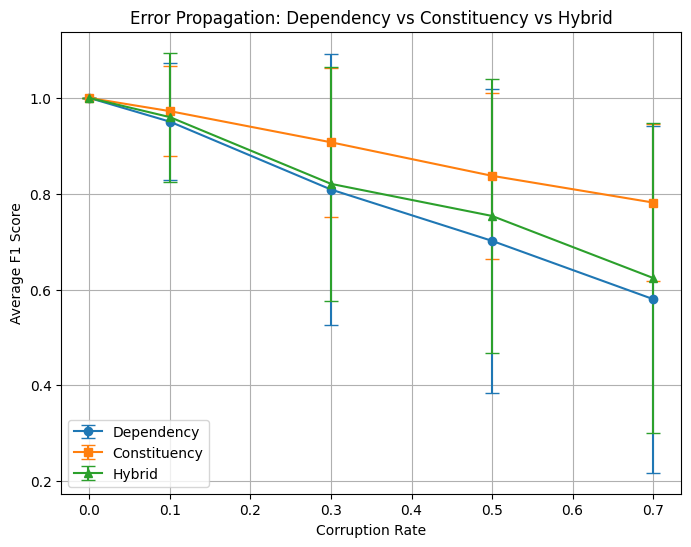

In [33]:
plt.figure(figsize=(8,6))

plt.errorbar(corruption_levels, means, yerr=stds,
             marker='o', capsize=5, label="Dependency")

plt.errorbar(corruption_levels, means_const, yerr=stds_const,
             marker='s', capsize=5, label="Constituency")

plt.errorbar(corruption_levels, means_hybrid, yerr=stds_hybrid,
             marker='^', capsize=5, label="Hybrid")

plt.xlabel("Corruption Rate")
plt.ylabel("Average F1 Score")
plt.title("Error Propagation: Dependency vs Constituency vs Hybrid")
plt.legend()
plt.grid(True)
plt.show()

Also, results if we want to use numbers results but not graphs:

In [34]:
results_table = pd.DataFrame({
    "Corruption": corruption_levels,
    "Dep Mean F1": means,
    "Dep Std": stds,
    "Const Mean F1": means_const,
    "Const Std": stds_const,
    "Hybrid Mean F1": means_hybrid,
    "Hybrid Std": stds_hybrid
})

print(results_table.round(3).to_string(index=False))

 Corruption  Dep Mean F1  Dep Std  Const Mean F1  Const Std  Hybrid Mean F1  Hybrid Std
        0.0        1.000    0.000          1.000      0.000           1.000       0.000
        0.1        0.950    0.123          0.972      0.094           0.960       0.135
        0.3        0.809    0.283          0.907      0.156           0.821       0.244
        0.5        0.702    0.317          0.838      0.173           0.754       0.286
        0.7        0.580    0.363          0.782      0.164           0.624       0.323


The results clearly show that SRL performance degrades as the level of syntactic corruption increases. For all three methods, F1-score steadily decreases with higher noise, confirming the presence of error propagation.

Dependency-based SRL is the most sensitive to corruption. At 70% noise, its average F1 drops to 0.58, with a relatively high standard deviation (0.36), indicating instability under heavy structural distortion. This is expected, since semantic roles in this method directly depend on correct head–dependent relations.

The constituency-based approach is noticeably more robust. Even at 70% corruption, it maintains an average F1 of 0.78, and its variance remains lower compared to the dependency method. Because this approach relies on phrase boundaries rather than individual dependency arcs, the errors affect it in a more localized way.

The hybrid model shows intermediate behavior. It consistently outperforms pure dependency-based SRL under noise, demonstrating that combining representations can partially mitigate cascading errors. However, it does not surpass the constituency-based method in this setup. This suggests that while hybridization improves robustness, its effectiveness depends on how the two representations complement each other.

Overall, the experiment confirms that different types of syntactic errors propagate differently into downstream tasks, and that combining structural signals can help reduce, but not completely eliminate, performance degradation.